# Robust Multimodal Fusion: Demo and Analysis

This notebook serves two primary purposes:
1. **Live Inference Demo**: Demonstrate the dynamic behaviour of the best-performing `GatedFusionModel` (gated_fusion_confw) by observing how its modality fusion gates (Audio vs. Text weights) adapt based on simulated ASR confidence scores.
2. **Results Analysis**: Visualize the final performance metrics (Weighted F1 Score) across all fusion strategies and the specific ablation studies.

## 1. Setup and Dependencies

This cell installs necessary libraries, configures the environment path to import custom modules, and defines flobal constants.

In [85]:
!pip install torch numpy pandas scikit-learn matplotlib

In [86]:
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from pathlib import Path

import warnings
warnings.filterwarnings('ignore') 

Configure path to import custom modules from the repository root.

In [87]:
notebook_dir = Path.cwd() 
repo_root = notebook_dir.parent 
sys.path.append(str(repo_root))

In [79]:
try:
    from src.gated_fusion_module.gated_fusion_dualtext import GatedFusionModelDualText
    from src.gated_fusion_module.confidence_gate import ConfidenceGate 
    from src.gated_fusion_module.dual_text_mixer import DualTextMixer 
    from src.gated_fusion_module.gated_fusion import GatedFusionModel
    
except ImportError as e:
    print(f"Error details: {e}")

Global constants.

In [88]:
INPUT_DIM = 768
HIDDEN_DIM = 256
NUM_CLASSES = 5

Target checkpoint path for the best model (gated_fusion_confw_dualtext).

In [89]:
CHECKPOINT_DIR = Path("results/gated_fusion_results/gated_fusion_confw_dualtext")
CHECKPOINT_FILENAME = "best_model.pt" 
MODEL_CHECKPOINT_PATH = repo_root / CHECKPOINT_DIR / CHECKPOINT_FILENAME 

EMOTION_MAP = {
    0: "Neutral",
    1: "Happy",
    2: "Sad",
    3: "Angry",
    4: "Excited"
}

Generates consistent mock features for reproducible demos.

In [81]:
def mock_feature(seed, dim=INPUT_DIM):
    np.random.seed(seed)
    feature = torch.tensor(np.random.rand(1, dim), dtype=torch.float32)
    return feature

Generates mock features and runs model inference.

In [90]:
def mock_inference(model, audio_seed, text_seed, confidence_score, desc):    
    # Prepare Mock Data: with a Batch size = 1
    # Three inputs for the DualText model: Audio (a), Text Mean (t_mean), Text Conf-Weighted (t_confw)
    a_feat = mock_feature(audio_seed)
    t_mean_feat = mock_feature(text_seed)
    t_confw_feat = mock_feature(text_seed + 1) 
    conf = torch.tensor([confidence_score], dtype=torch.float32) 

    # Run inference
    with torch.no_grad():
        output = model(
            audio_features=a_feat,            
            text_features=t_mean_feat,         
            confidence=conf,
            text_conf=t_confw_feat        
        )
        logits = output['logits']
        g_a, g_t = output['gates'][:, 0:1].item(), output['gates'][:, 1:2].item()
        predicted_id = torch.argmax(logits, dim=1).item()
        
    # Show the results
    print(f"\n--- Scenario: {desc} ---")
    print(f"  Input ASR Conf. (c): {confidence_score:.4f}")
    print(f"  Gate Weights (A/T): {g_a:.3f} / {g_t:.3f} (Sum: {g_a+g_t:.3f})")
    print(f"  Predicted Emotion: {EMOTION_MAP.get(predicted_id)}")

## 2. Live Inference Demo: Dynamic Gating
This section loads the best-performing model and runs two mock scenarios to demonstrate how the **Confidence Gate** dynamically adjusts the weights assigned to the Audio and Text modalities based on the ASR confidence score. We confirm the model configuration matches the checkpoint.

In [91]:
# load model
model = GatedFusionModel(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    use_conf_in_gate=True,
    use_aux_loss=False,      
    scale_text_by_conf=False 
)

In [92]:
try:
    # 1. Load the entire checkpoint dictionary and extract the state_dict
    checkpoint = torch.load(MODEL_CHECKPOINT_PATH, map_location='cpu')
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    
    # 2. Load the state dictionary, using strict=False to ignore the minor differences (log_tau, norm)
    # The return value (load_info) contains the list of missing and unexpected keys.
    load_info = model.load_state_dict(state_dict, strict=False)
    model.eval()
    
    print(f"Best Gated Fusion model ({model.__class__.__name__}) loaded successfully and ready for inference.")
    
    # Run Demo Cases
    # Case 1: High Confidence (Model should rely more on Text, low g_a/high g_t)
    mock_inference(model, 1, 2, 0.95, "High ASR Confidence (Text is Reliable)")

    # Case 2: Low Confidence (Model should rely more on Audio, high g_a/low g_t)
    mock_inference(model, 1, 2, 0.15, "Low ASR Confidence (Text is Unreliable)")

except FileNotFoundError:
    print("Please ensure you have trained and saved your best model to this location.")

Best Gated Fusion model (GatedFusionModel) loaded successfully and ready for inference.

--- Scenario: High ASR Confidence (Text is Reliable) ---
  Input ASR Conf. (c): 0.9500
  Gate Weights (A/T): 0.403 / 0.597 (Sum: 1.000)
  Predicted Emotion: Happy

--- Scenario: Low ASR Confidence (Text is Unreliable) ---
  Input ASR Conf. (c): 0.1500
  Gate Weights (A/T): 0.489 / 0.511 (Sum: 1.000)
  Predicted Emotion: Happy


## Main Comparison

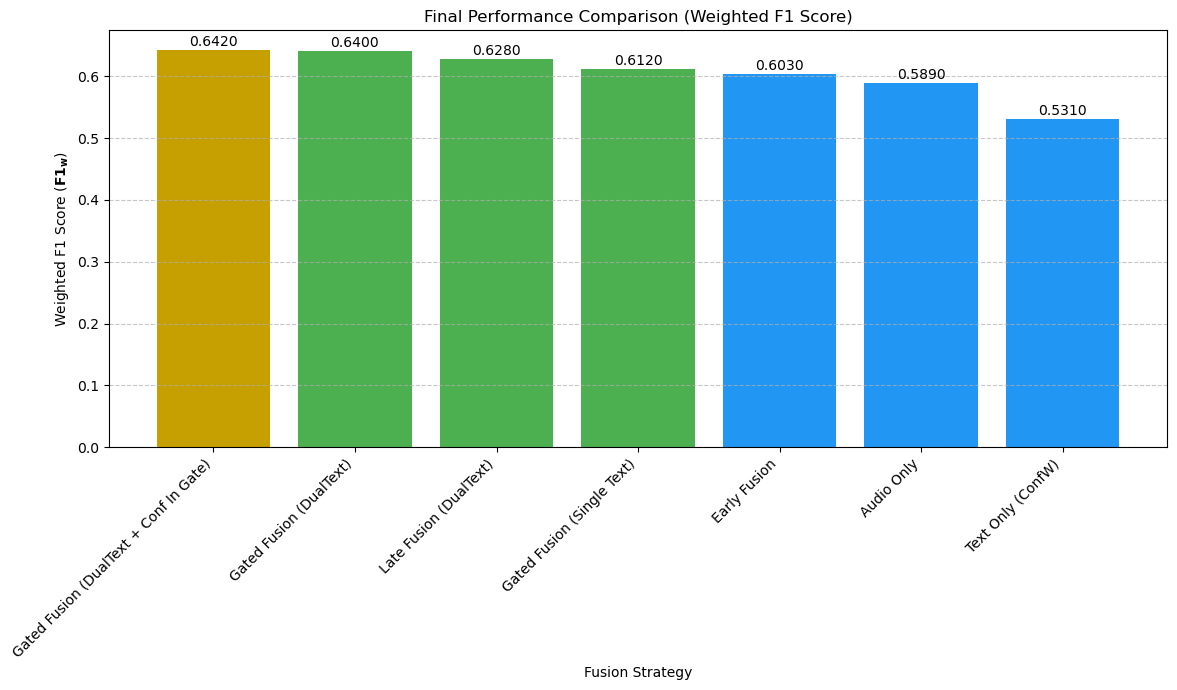

In [105]:
COLOR_BASELINE = '#2196F3' 
COLOR_GATED_FUSION = '#4CAF50' 
COLOR_BEST_MODEL = '#C5A000' 

RESULTS = {
    "Text Only (ConfW)": 0.531,
    "Audio Only": 0.589,
    "Early Fusion": 0.603,
    "Gated Fusion (Single Text)": 0.612,
    "Late Fusion (DualText)": 0.628,
    "Gated Fusion (DualText)": 0.640,
    "Gated Fusion (DualText + Conf In Gate)": 0.642,
}
# Convert to DataFrame for easy plotting
df = pd.DataFrame(list(RESULTS.items()), columns=['Model', 'F1_Weighted'])
df = df.sort_values(by='F1_Weighted', ascending=False)

# Plot 1
def get_main_color(model_name):
    if 'Gated Fusion (DualText + Conf In Gate)' in model_name:
        return COLOR_BEST_MODEL
    elif 'Gated Fusion' in model_name or 'Late Fusion' in model_name:
        return COLOR_GATED_FUSION
    else:
        return COLOR_BASELINE

colors_main = [get_main_color(model) for model in df['Model']]

plt.figure(figsize=(12, 7))
bars = plt.bar(df['Model'], df['F1_Weighted'], color=colors_main)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.002, f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

plt.title('Final Performance Comparison (Weighted F1 Score)')
plt.ylabel('Weighted F1 Score ($\mathbf{F1}_{\mathbf{w}}$)')
plt.xlabel('Fusion Strategy')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Gated Fusion Ablation Study 

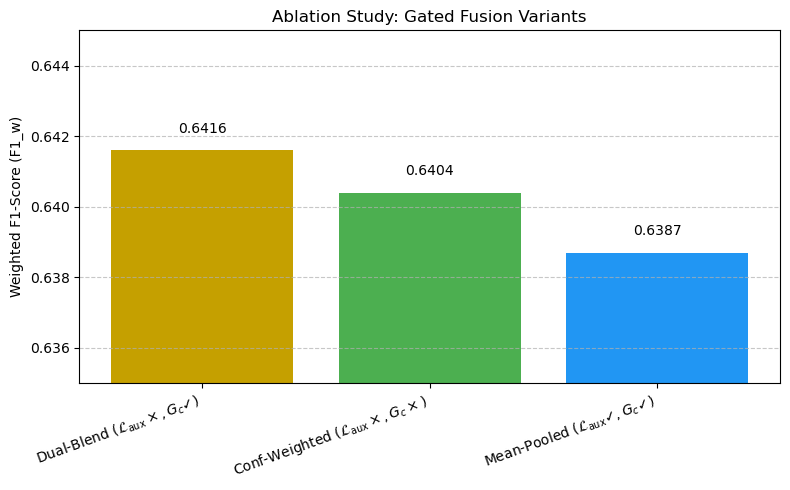

In [110]:
# Plot 2:
data_ablation = {
    'Variant': ['Mean-Pooled ($\mathcal{L}_{\\text{aux}} \\checkmark, G_{c} \\checkmark$)', 
                'Conf-Weighted ($\mathcal{L}_{\\text{aux}} \\times, G_{c} \\times$)', 
                'Dual-Blend ($\mathcal{L}_{\\text{aux}} \\times, G_{c} \\checkmark$)'],
    'F1_w': [0.6387, 0.6404, 0.6416]
}
df_ablation = pd.DataFrame(data_ablation)
df_ablation = df_ablation.sort_values(by='F1_w', ascending=False).reset_index(drop=True)
colors_ablation = [COLOR_BEST_MODEL, COLOR_GATED_FUSION, COLOR_BASELINE] 

plt.figure(figsize=(8, 5))
bars = plt.bar(df_ablation['Variant'], df_ablation['F1_w'], color=colors_ablation)

plt.ylim(0.635, 0.645)
plt.title('Ablation Study: Gated Fusion Variants')
plt.ylabel('Weighted F1-Score (F1_w)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.0005, f'{yval:.4f}', ha='center', fontsize=10)

plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()